# Advance Bank Term Deposit

## Introduction
This notebook provides a detailed analysis of customer behavior and insights into factors influencing term deposit subscription.

## Load Dataset

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df=pd.read_csv('/content/data.csv')
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [ ]:
df.head(40)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
5,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
6,59,admin.,married,professional.course,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
7,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
8,24,technician,single,professional.course,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
9,25,services,single,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [ ]:
df.isna().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [ ]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


## Customer Demographics Analysis

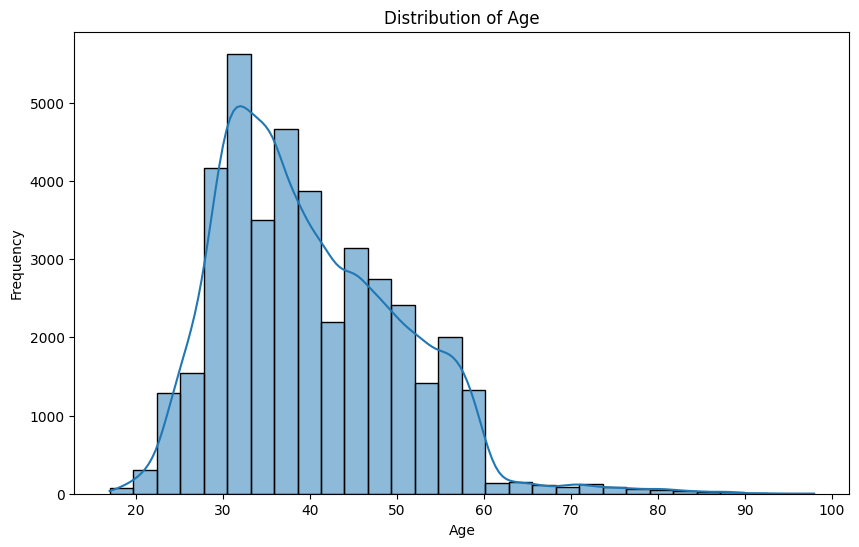

In [ ]:
# Age distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['age'], bins=30, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

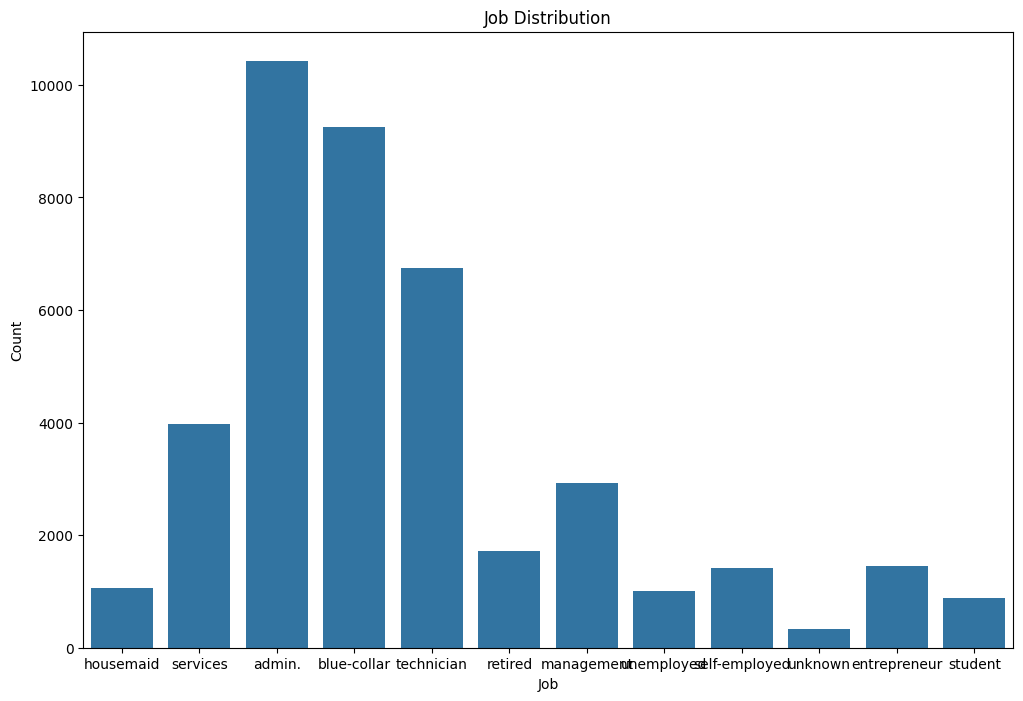

In [ ]:
# Job distribution
plt.figure(figsize=(12,8))
sns.countplot(x='job',data=df)
plt.title('Job Distribution')
plt.xlabel('Job')
plt.ylabel('Count')
plt.show()

## Balance & Deposit Trends

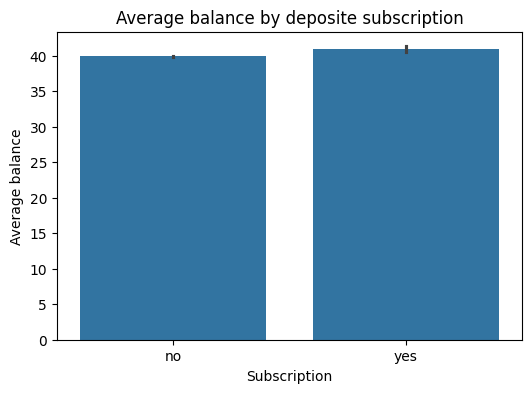

In [ ]:
# Average balance by deposit subscription
plt.figure(figsize=(6,4))
sns.barplot(x='y',y='age',data=df)
plt.title('Average balance by deposite subscription')
plt.xlabel('Subscription')
plt.ylabel('Average balance')
plt.show()

## Campaign Effectiveness

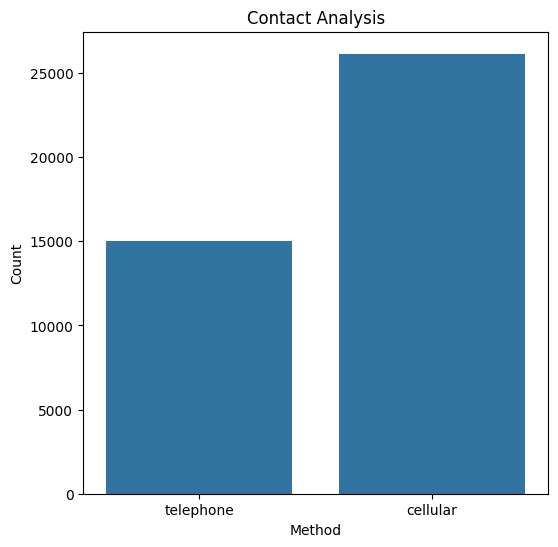

In [ ]:
# Contact method analysis
plt.figure(figsize=(6,6))
sns.countplot(x='contact',data=df)
plt.title('Contact Analysis')
plt.xlabel('Method')
plt.ylabel('Count')
plt.show()

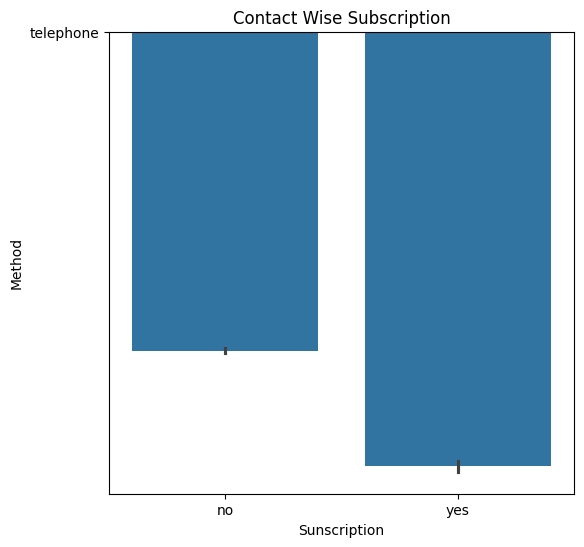

In [ ]:
# Number of contacts vs deposit subscription
plt.figure(figsize=(6,6))
sns.barplot(x='y',y='contact',data=df)
plt.title('Contact Wise Subscription')
plt.xlabel('Sunscription')
plt.ylabel('Method')
plt.show()

## Correlation Heatmap

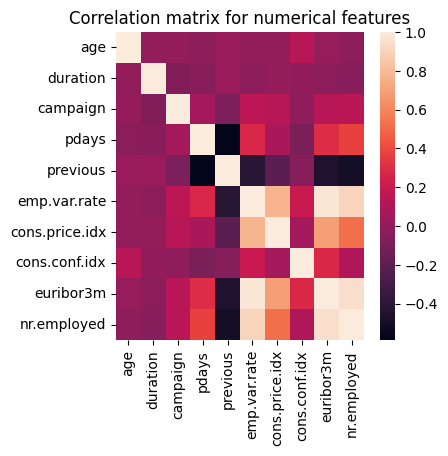

In [ ]:
# Correlation of numerical variables
plt.figure(figsize=(4, 4))
sns.heatmap(df.corr(numeric_only=True), fmt='.2f')
plt.title('Correlation matrix for numerical features')
plt.show()

## Predictive Modeling (Logistic Regression)

In [ ]:


# Encode categorical variables
encoded=pd.get_dummies(df,columns=['job'],dtype=int)
encoded
# Predictions


,age,marital,education,default,housing,loan,contact,month,day_of_week,duration,...,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown
0,56,married,basic.4y,no,no,no,telephone,may,mon,261,...,0,1,0,0,0,0,0,0,0,0
1,57,married,high.school,unknown,no,no,telephone,may,mon,149,...,0,0,0,0,0,1,0,0,0,0
2,37,married,high.school,no,yes,no,telephone,may,mon,226,...,0,0,0,0,0,1,0,0,0,0
3,40,married,basic.6y,no,no,no,telephone,may,mon,151,...,0,0,0,0,0,0,0,0,0,0
4,56,married,high.school,no,no,yes,telephone,may,mon,307,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,married,professional.course,no,yes,no,cellular,nov,fri,334,...,0,0,0,1,0,0,0,0,0,0
41184,46,married,professional.course,no,no,no,cellular,nov,fri,383,...,0,0,0,0,0,0,0,0,0,0
41185,56,married,university.degree,no,yes,no,cellular,nov,fri,189,...,0,0,0,1,0,0,0,0,0,0
41186,44,married,professional.course,no,no,no,cellular,nov,fri,442,...,0,0,0,0,0,0,0,1,0,0


In [ ]:
encoded1=pd.get_dummies(df,columns=['marital'],dtype=int)
encoded1


,age,job,education,default,housing,loan,contact,month,day_of_week,duration,...,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,marital_divorced,marital_married,marital_single,marital_unknown
0,56,housemaid,basic.4y,no,no,no,telephone,may,mon,261,...,1.1,93.994,-36.4,4.857,5191.0,no,0,1,0,0
1,57,services,high.school,unknown,no,no,telephone,may,mon,149,...,1.1,93.994,-36.4,4.857,5191.0,no,0,1,0,0
2,37,services,high.school,no,yes,no,telephone,may,mon,226,...,1.1,93.994,-36.4,4.857,5191.0,no,0,1,0,0
3,40,admin.,basic.6y,no,no,no,telephone,may,mon,151,...,1.1,93.994,-36.4,4.857,5191.0,no,0,1,0,0
4,56,services,high.school,no,no,yes,telephone,may,mon,307,...,1.1,93.994,-36.4,4.857,5191.0,no,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,professional.course,no,yes,no,cellular,nov,fri,334,...,-1.1,94.767,-50.8,1.028,4963.6,yes,0,1,0,0
41184,46,blue-collar,professional.course,no,no,no,cellular,nov,fri,383,...,-1.1,94.767,-50.8,1.028,4963.6,no,0,1,0,0
41185,56,retired,university.degree,no,yes,no,cellular,nov,fri,189,...,-1.1,94.767,-50.8,1.028,4963.6,no,0,1,0,0
41186,44,technician,professional.course,no,no,no,cellular,nov,fri,442,...,-1.1,94.767,-50.8,1.028,4963.6,yes,0,1,0,0


In [ ]:
encoded2=pd.get_dummies(df,columns=['contact'],dtype=int)
encoded2


,age,job,marital,education,default,housing,loan,month,day_of_week,duration,...,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,contact_cellular,contact_telephone
0,56,housemaid,married,basic.4y,no,no,no,may,mon,261,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0,1
1,57,services,married,high.school,unknown,no,no,may,mon,149,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0,1
2,37,services,married,high.school,no,yes,no,may,mon,226,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0,1
3,40,admin.,married,basic.6y,no,no,no,may,mon,151,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0,1
4,56,services,married,high.school,no,no,yes,may,mon,307,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,nov,fri,334,...,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes,1,0
41184,46,blue-collar,married,professional.course,no,no,no,nov,fri,383,...,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no,1,0
41185,56,retired,married,university.degree,no,yes,no,nov,fri,189,...,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no,1,0
41186,44,technician,married,professional.course,no,no,no,nov,fri,442,...,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes,1,0


### Model Training and Prediction

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Create a pipeline with preprocessing and Logistic Regression
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', random_state=42))
])

In [ ]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Train the model
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='object'))])),
                ('classifier',
                 LogisticRegression(random_state=42, solver='liblinear'))])

In [ ]:
# Make predictions on the test set
y_pred = model.predict(X_test)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Confusion Matrix:
[[10703   262]
 [  842   550]]


### Model Training and Prediction

### Feature Importance

In [ ]:
# Feature importance


### Feature Importance

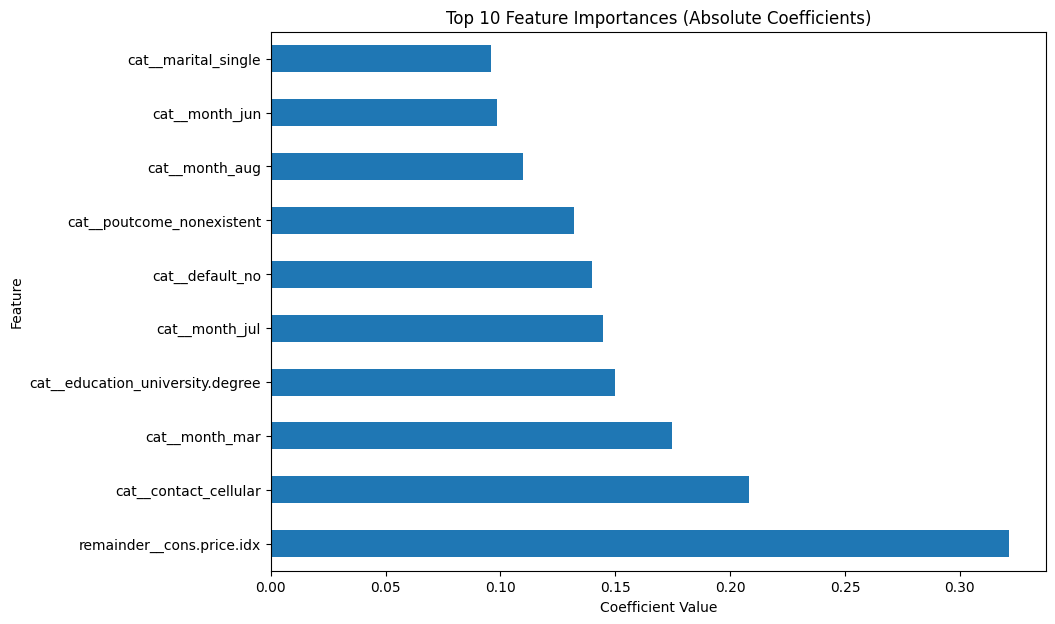

In [ ]:
# Get the trained Logistic Regression model from the pipeline
logistic_model = model.named_steps['classifier']

# Get feature names after one-hot encoding
encoded_feature_names = model.named_steps['preprocessor'].get_feature_names_out()

# Get coefficients (feature importance) from the logistic regression model
feature_importances = pd.Series(logistic_model.coef_[0], index=encoded_feature_names)

# Sort and display top N important features (e.g., top 10)
plt.figure(figsize=(10, 7))
feature_importances.nlargest(10).plot(kind='barh')
plt.title('Top 10 Feature Importances (Absolute Coefficients)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.show()

## Key Takeaways
- Certain age groups and job categories are more likely to subscribe.
- Higher balances correlate with higher subscription rates.
- Cellular contact is more effective than telephone.
- Campaign duration and number of contacts influence outcomes.
- Logistic regression shows which features are strongest predictors.